# Stock Treemap Visualization
Display stocks as treemaps using squarify with size proportional to gains across multiple periods

## 1. Imports

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

print('Imports OK')

Imports OK


## 2. Load Data

In [46]:
# Load returns data
df = pd.read_csv('dump/returns_table.csv')
print(f'Loaded {len(df)} stocks')
df.head()

Loaded 124 stocks


,Symbol,Current_Price,2D_%,5D_%,10D_%,1M_%,3M_%,6M_%,1Y_%
0,HEROMOTOCO,5480.00,-1.94,-4.03,0.27,-4.96,-13.71,2.42,52.95
1,TATASTEEL,191.01,-4.77,-10.04,-8.33,-3.41,16.85,12.87,23.50
2,ICICIBANK,1278.40,-5.83,-7.29,-8.33,-8.46,-8.00,-8.94,5.23
3,GAIL,148.98,-4.94,-12.12,-11.57,-6.99,-12.35,-13.57,-3.97
4,INFY,1315.00,0.70,1.15,-2.82,-13.50,-18.64,-14.20,-20.86


## 3. Prepare Data for Multiple Periods

In [47]:
# Define periods to visualize
periods = ['1M_%', '3M_%', '6M_%', '1Y_%']
period_labels = {'1M_%': '1 Month', '3M_%': '3 Months', '6M_%': '6 Months', '1Y_%': '1 Year'}

# Filter gainers for each period
def get_gainers(df, period_col, top_n=30):
    """Get top N gainers for a period, excluding NaN values"""
    gainers = df[df[period_col] > 0].copy()
    gainers = gainers.dropna(subset=[period_col])
    gainers = gainers.nlargest(top_n, period_col)
    return gainers[['Symbol', period_col]]

# Get gainers for each period
period_data = {}
for period in periods:
    gainers = get_gainers(df, period, top_n=30)
    period_data[period] = gainers
    print(f'{period_labels[period]}: {len(gainers)} gainers')

1 Month: 28 gainers
3 Months: 30 gainers
6 Months: 30 gainers
1 Year: 3 gainers


## 4. Create Treemap for Single Period

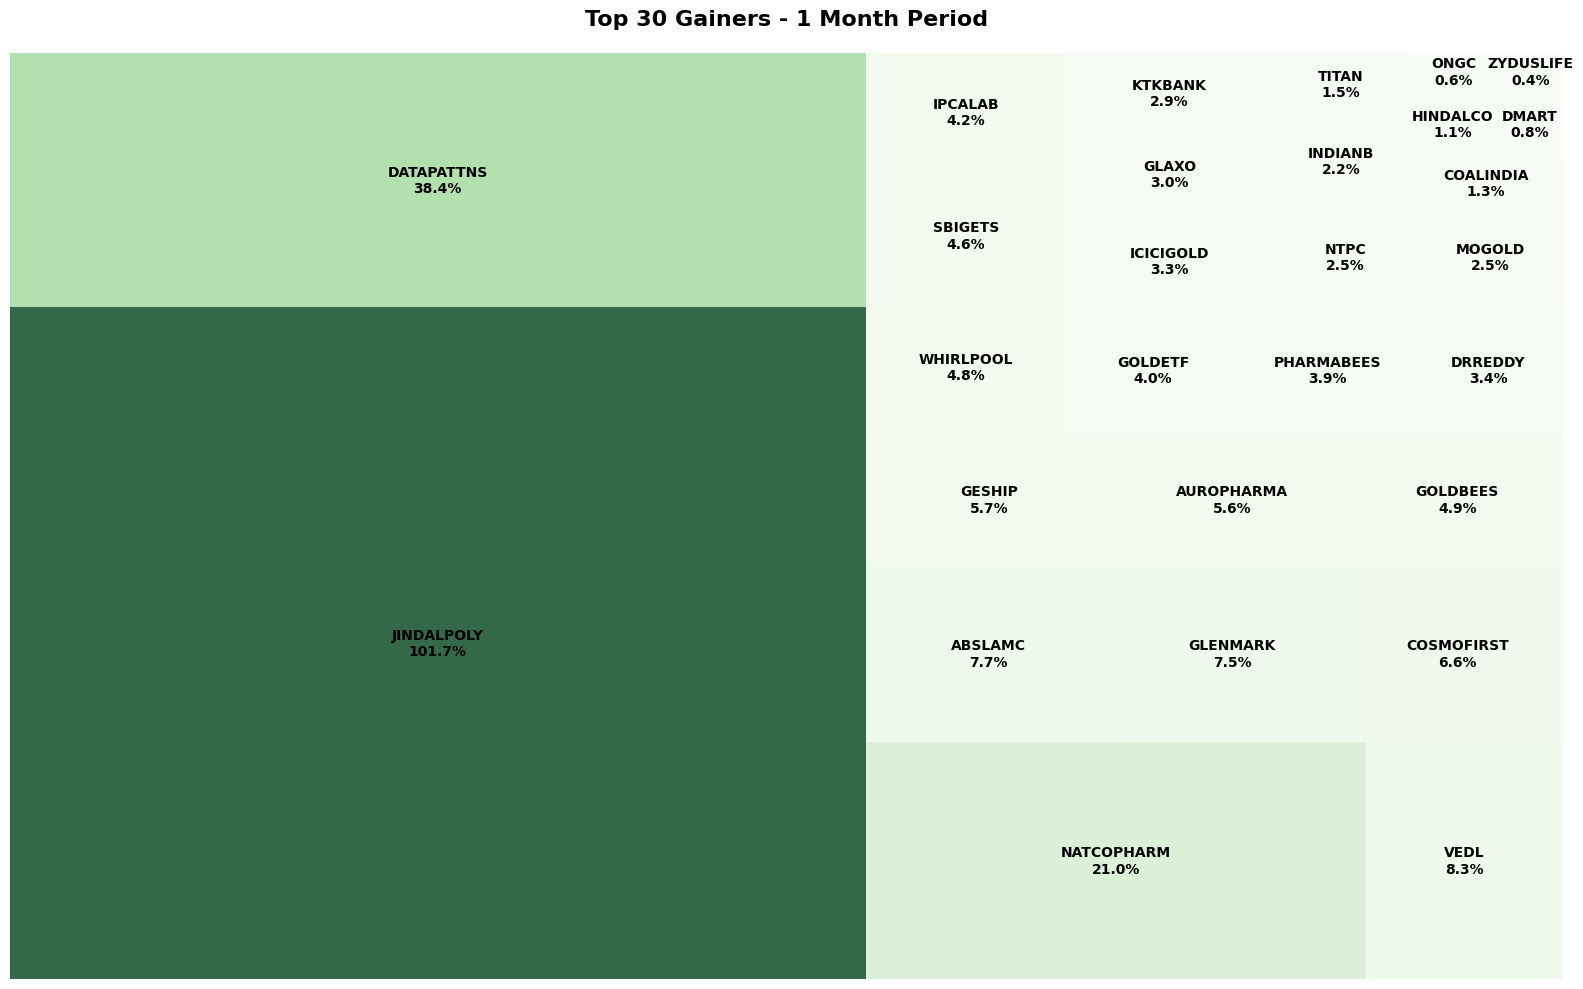

In [48]:
def create_treemap(data, period_col, title):
    """Create a treemap for a single period"""
    if len(data) == 0:
        print(f'No data for {title}')
        return None
    
    # Prepare data
    labels = [f"{row['Symbol']}\n{row[period_col]:.1f}%" for _, row in data.iterrows()]
    sizes = data[period_col].values
    
    # Color mapping: darker green = higher gain
    colors = plt.cm.Greens(sizes / sizes.max())
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Create treemap
    squarify.plot(
        sizes=sizes,
        label=labels,
        color=colors,
        alpha=0.8,
        text_kwargs={'fontsize': 10, 'weight': 'bold'},
        ax=ax
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    
    return fig

# Example: Create treemap for 1M period
fig = create_treemap(period_data['1M_%'], '1M_%', 'Top 30 Gainers - 1 Month Period')
if fig:
    plt.show()
    plt.close(fig)

## 5. Create Multi-Period Treemap Grid

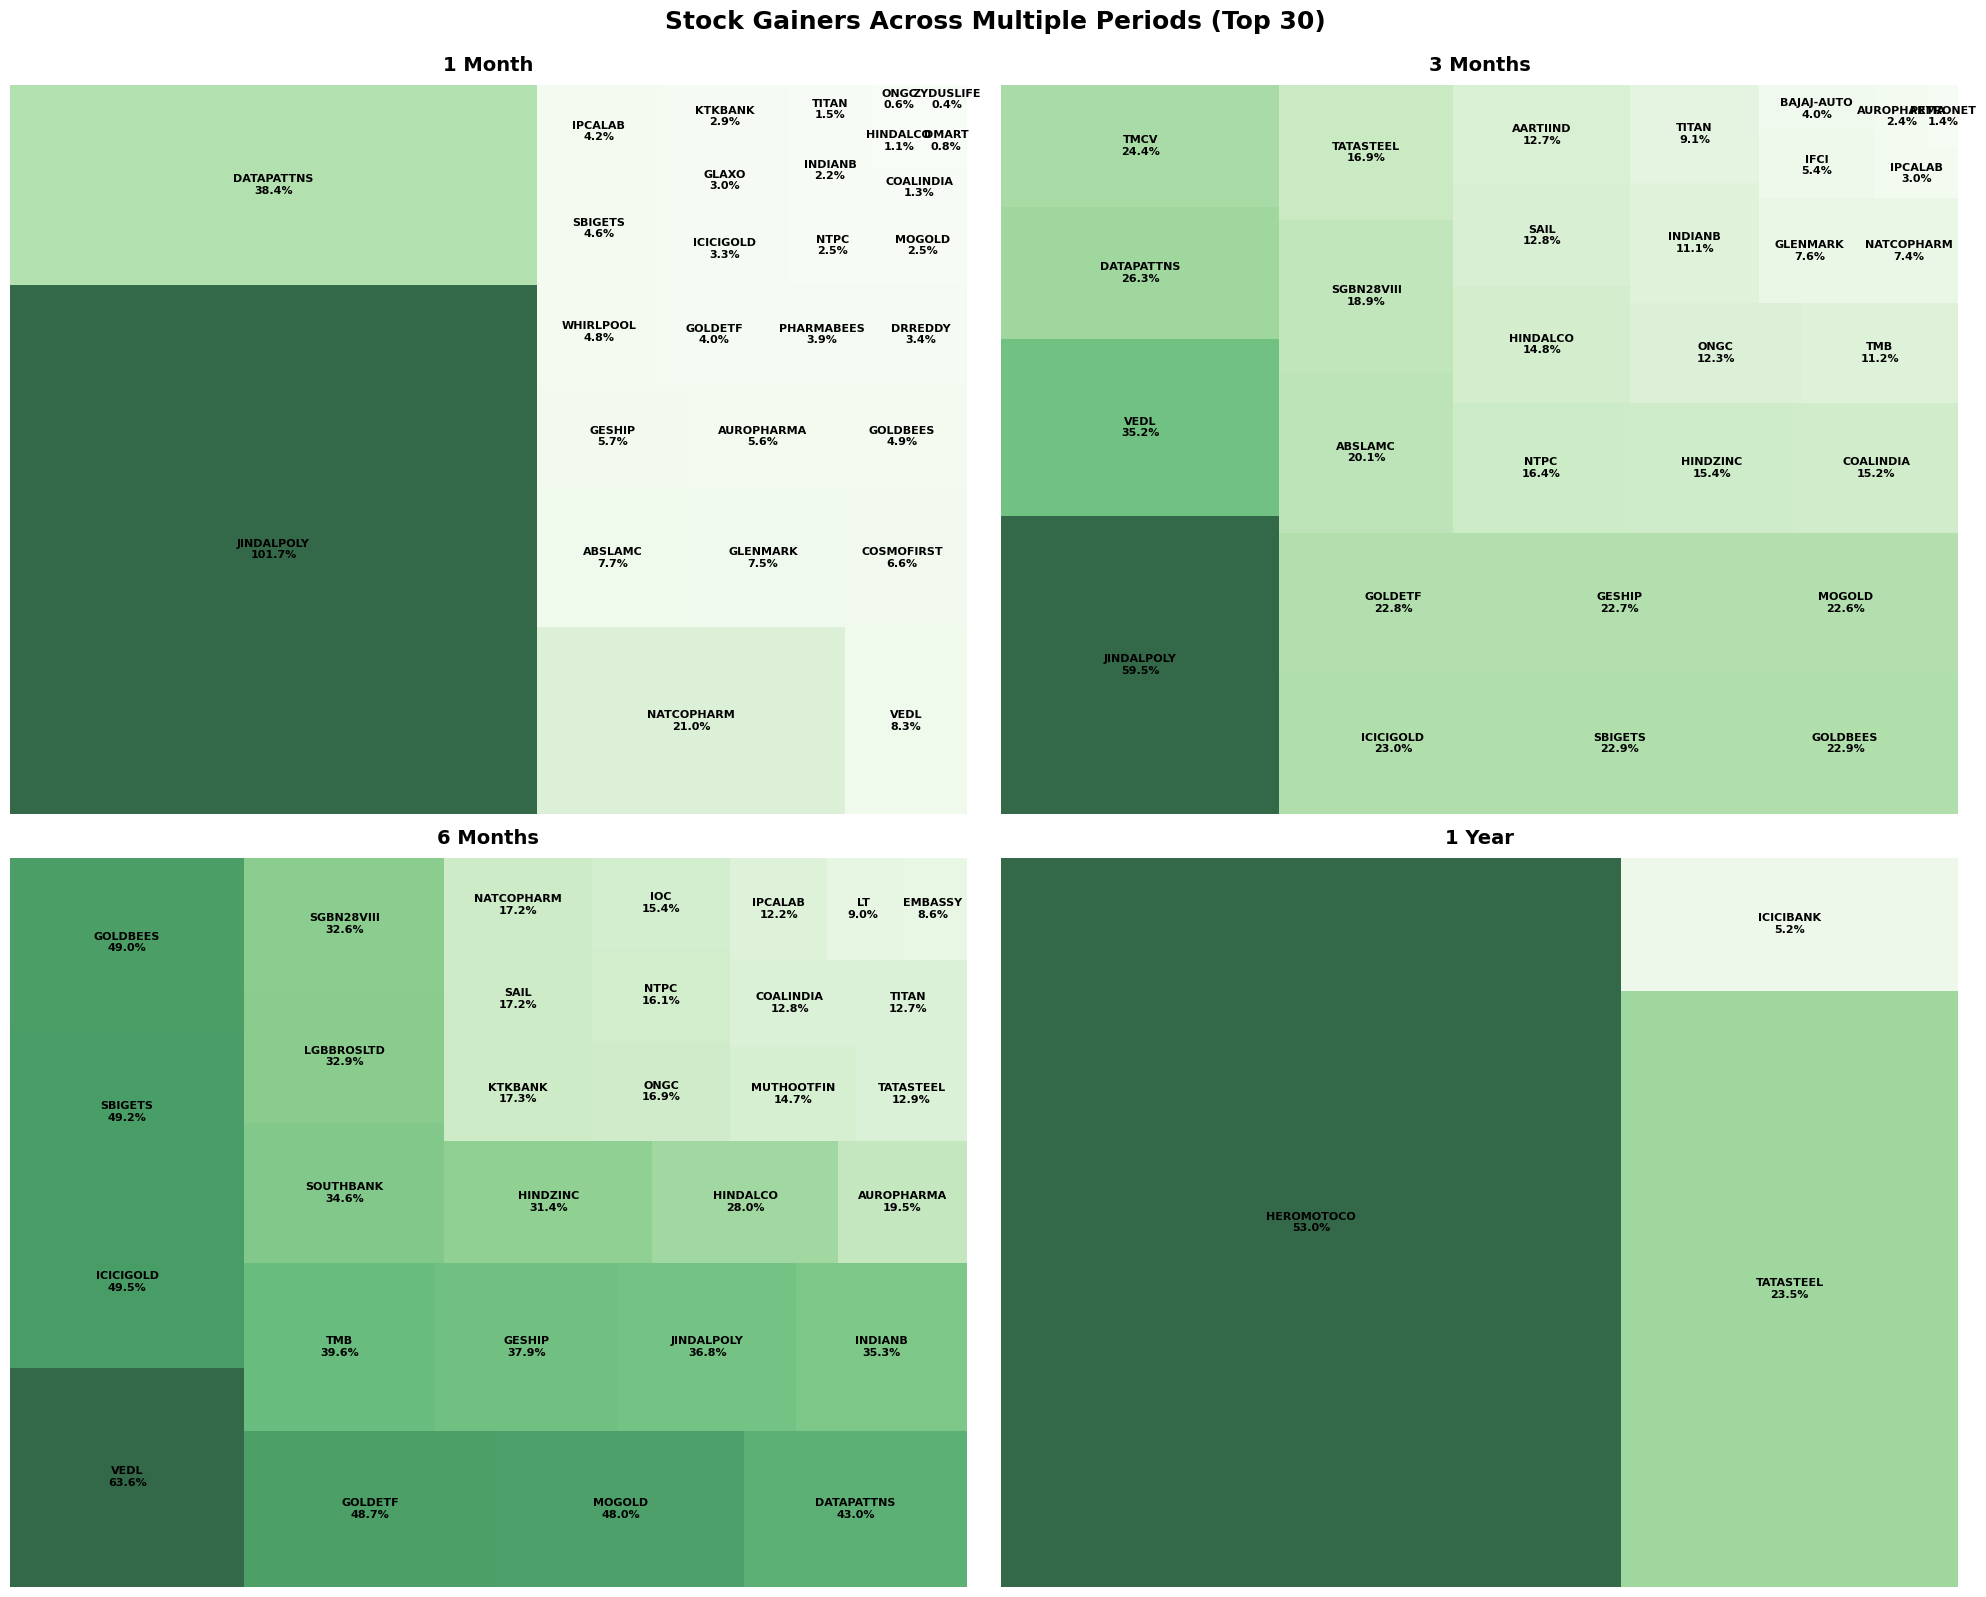


Multi-period treemap saved to dump/stock_treemap_multi_period.png


In [49]:
# Create 2x2 grid of treemaps for all periods
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Stock Gainers Across Multiple Periods (Top 30)', fontsize=18, fontweight='bold', y=0.995)

for idx, (period, ax) in enumerate(zip(periods, axes.flatten())):
    data = period_data[period]
    
    if len(data) == 0:
        ax.text(0.5, 0.5, f'No gainers for {period_labels[period]}', 
                ha='center', va='center', fontsize=14)
        ax.axis('off')
        continue
    
    # Prepare data
    labels = [f"{row['Symbol']}\n{row[period]:.1f}%" for _, row in data.iterrows()]
    sizes = data[period].values
    
    # Color mapping
    colors = plt.cm.Greens(sizes / sizes.max())
    
    # Create treemap
    squarify.plot(
        sizes=sizes,
        label=labels,
        color=colors,
        alpha=0.8,
        text_kwargs={'fontsize': 8, 'weight': 'bold'},
        ax=ax
    )
    
    ax.set_title(period_labels[period], fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Save
output_path = 'dump/stock_treemap_multi_period.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f'\nMulti-period treemap saved to {output_path}')

## 6. Create Combined Treemap (All Periods in One)

Combined treemap: 40 unique stocks


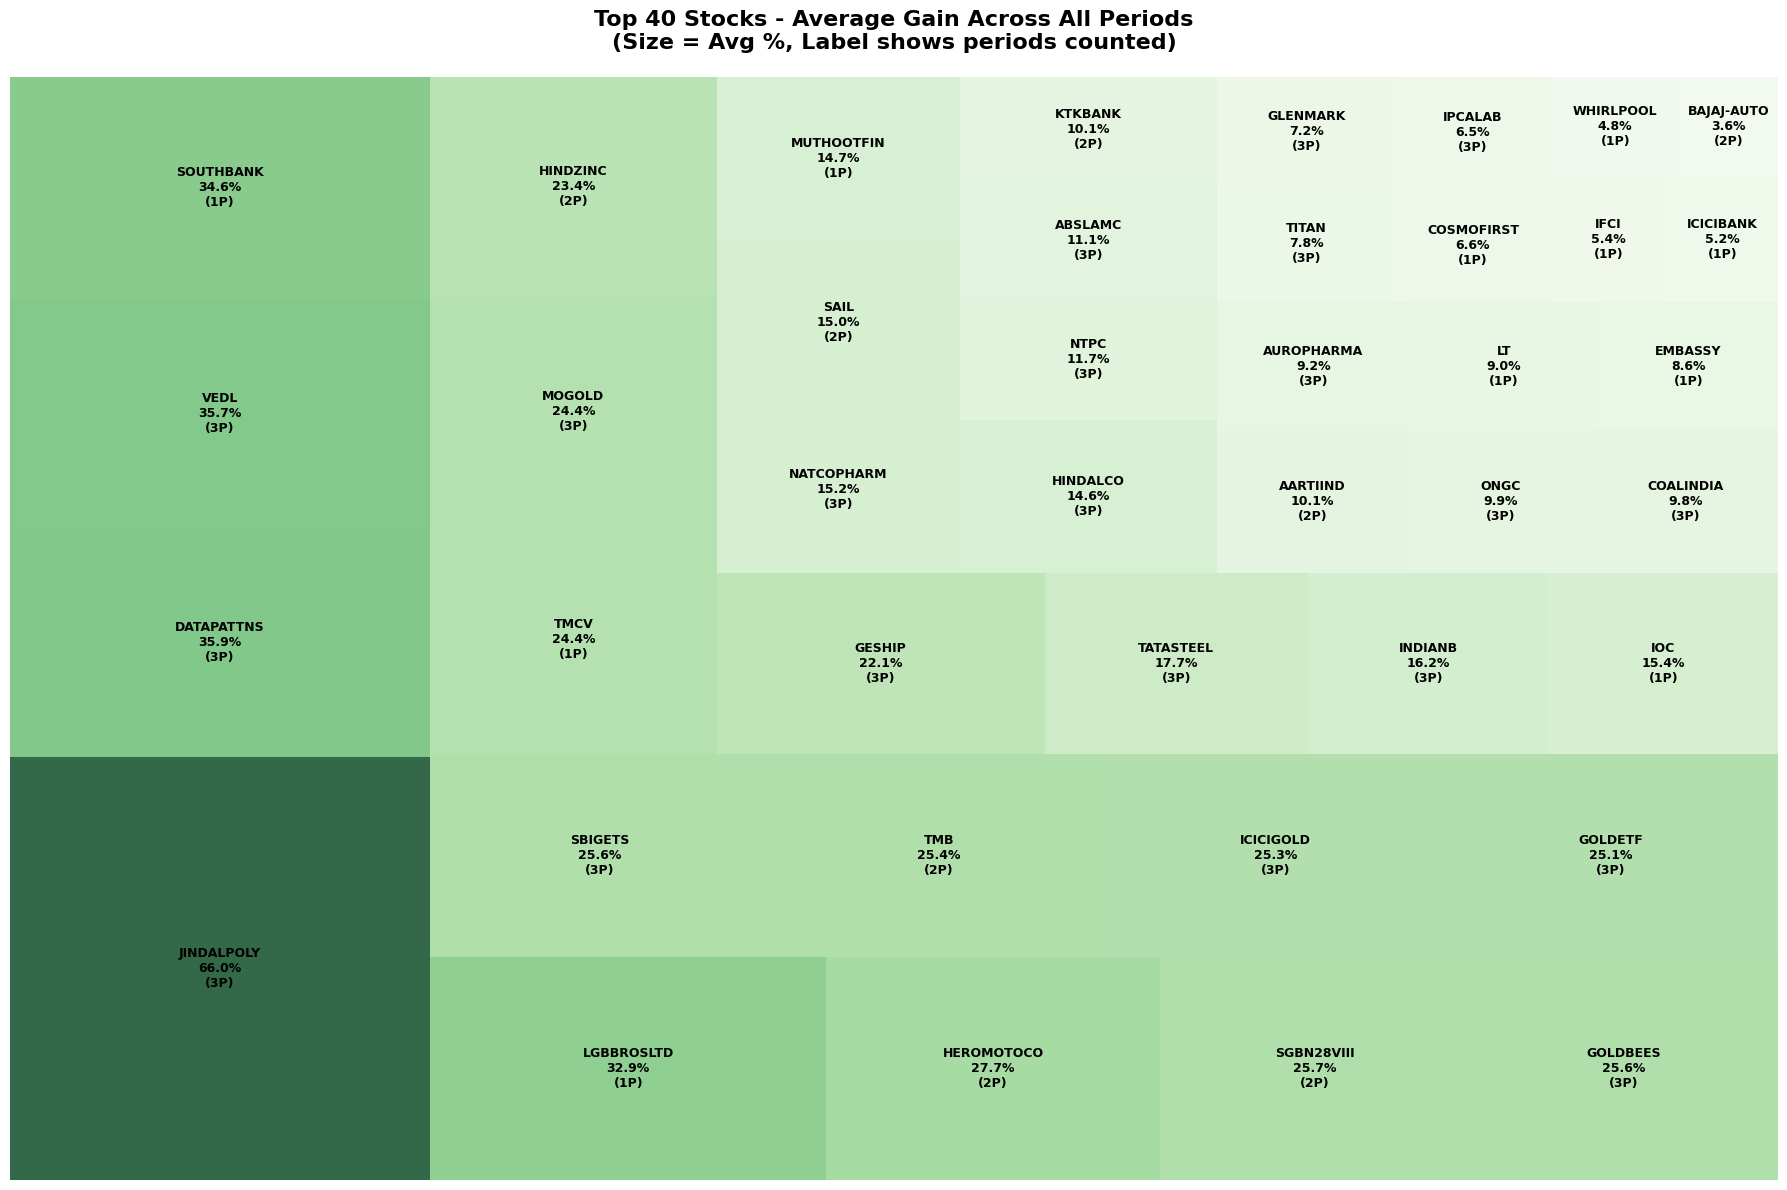

Combined treemap saved to dump/stock_treemap_combined.png


In [50]:
# Combine top gainers across all periods (unique stocks)
# Use average gain across available periods as size metric

combined_stocks = set()
for period in periods:
    combined_stocks.update(period_data[period]['Symbol'].tolist())

# Calculate average gain for each stock across periods
combined_data = []
for symbol in combined_stocks:
    stock_row = df[df['Symbol'] == symbol].iloc[0]
    gains = [stock_row[p] for p in periods if pd.notna(stock_row[p]) and stock_row[p] > 0]
    if gains:
        avg_gain = sum(gains) / len(gains)
        combined_data.append({
            'Symbol': symbol,
            'Avg_Gain': avg_gain,
            'Periods': len(gains)
        })

combined_df = pd.DataFrame(combined_data)
combined_df = combined_df.nlargest(40, 'Avg_Gain')

print(f'Combined treemap: {len(combined_df)} unique stocks')

# Create combined treemap
fig, ax = plt.subplots(figsize=(18, 12))

labels = [f"{row['Symbol']}\n{row['Avg_Gain']:.1f}%\n({row['Periods']}P)" 
          for _, row in combined_df.iterrows()]
sizes = combined_df['Avg_Gain'].values
colors = plt.cm.Greens(sizes / sizes.max())

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.8,
    text_kwargs={'fontsize': 9, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Top 40 Stocks - Average Gain Across All Periods\n(Size = Avg %, Label shows periods counted)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Save
output_path = 'dump/stock_treemap_combined.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f'Combined treemap saved to {output_path}')

## 7. Summary Statistics

In [51]:
# Show top performers across periods
print('\n=== TOP PERFORMERS BY PERIOD ===')
for period in periods:
    data = period_data[period]
    if len(data) > 0:
        print(f'\n{period_labels[period]}:')
        print(data.head(5).to_string(index=False))


=== TOP PERFORMERS BY PERIOD ===

1 Month:
    Symbol   1M_%
JINDALPOLY 101.72
DATAPATTNS  38.43
NATCOPHARM  20.96
      VEDL   8.27
   ABSLAMC   7.71

3 Months:
    Symbol  3M_%
JINDALPOLY 59.51
      VEDL 35.25
DATAPATTNS 26.28
      TMCV 24.41
 ICICIGOLD 23.00

6 Months:
   Symbol  6M_%
     VEDL 63.57
ICICIGOLD 49.48
  SBIGETS 49.17
 GOLDBEES 48.99
  GOLDETF 48.70

1 Year:
    Symbol  1Y_%
HEROMOTOCO 52.95
 TATASTEEL 23.50
 ICICIBANK  5.23
